# Workflow for a single node energy system

In this application of the ETHOS.FINE framework, a single region energy system is modeled and optimized.

All classes which are available to the user are utilized and examples of the selection of different parameters within these classes are given.

The workflow is structures as follows:
1. Required packages are imported and the input data path is set
2. An energy system model instance is created
3. Commodity sources are added to the energy system model
4. Commodity conversion components are added to the energy system model
5. Commodity storages are added to the energy system model
7. Commodity sinks are added to the energy system model
8. The energy system model is optimized
9. Selected optimization results are presented


# 1. Import required packages and set input data path

The ETHOS.FINE framework is imported which provides the required classes and functions for modeling the energy system.

In [1]:
import fine as fn
from getData import getData
from pathlib import Path


cwd = Path.cwd()
data = getData()

%matplotlib inline
%load_ext autoreload
%autoreload 2

# 2. Create an energy system model instance 

The structure of the energy system model is given by the considered locations, commodities, the number of time steps as well as the hours per time step.

The commodities are specified by a unit (i.e. 'GW_electric', 'GW_H2lowerHeatingValue', 'Mio. t CO2/h') which can be given as an energy or mass unit per hour. Furthermore, the cost unit and length unit are specified.

In [2]:
locations = {"GermanyRegion"}
onlycommodityUnitsDict = {"electricity": r"GW$_{el}$", "hydrogen": r"GW$_{H_{2},LHV}$"}
onlycommodities = {"electricity", "hydrogen"}
onlymaterials= {"steel", "copper"}
onlymaterialUnitsDict= {"steel": r"tons$", "copper": r"tons$"}
numberOfTimeSteps = 8760
hoursPerTimeStep = 1

In [3]:
esM = fn.EnergySystemModel(
    locations=locations,
    onlycommodities=onlycommodities,
    onlymaterials=onlymaterials, 
    numberOfTimeSteps=8760,
    onlycommodityUnitsDict=onlycommodityUnitsDict,
    onlymaterialUnitsDict=onlymaterialUnitsDict,
    hoursPerTimeStep=1,
    costUnit="1e9 Euro",
    lengthUnit="km",
    verboseLogLevel=0,
)

# 3. Add commodity sources to the energy system model

## 3.1. Electricity sources

### Wind onshore

In [4]:
import pandas as pd

esM.add(
    fn.Source(
        esM=esM,
        name="Wind (onshore)",
        commodity="electricity",
        hasCapacityVariable=True,
        operationRateMax=data["Wind (onshore), operationRateMax"],
        capacityMax=data["Wind (onshore), capacityMax"],
        investPerCapacity=1.1,
        opexPerCapacity=1.1 * 0.02,
        interestRate=0.08,
        economicLifetime=20,
        materialIntensity = {
            'GermanyRegion': {
                'steel': pd.Series({0: 3.1}, dtype='float64'),
                'copper': pd.Series({0: 5.3}, dtype='float64')  
            }
        }
    )
)

esM.add(
    fn.Source(
        esM=esM,
        name="Wind (offshore)",
        commodity="electricity",
        hasCapacityVariable=True,
        operationRateMax=data["Wind (onshore), operationRateMax"],
        capacityMax=data["Wind (onshore), capacityMax"],
        investPerCapacity=1.1,
        opexPerCapacity=1.1 * 0.02,
        interestRate=0.08,
        economicLifetime=20,
        materialIntensity = {
            'GermanyRegion': {
                'steel': pd.Series({0: 3.1}, dtype='float64'),
                'copper': pd.Series({0: 5.3}, dtype='float64')  
            }
        }
    )
)

Full load hours:

In [5]:
data["Wind (onshore), operationRateMax"].sum()

2300.4069071646272

# 4. Add conversion components to the energy system model

### New combined cycly gas turbines for hydrogen

In [6]:
esM.add(
    fn.Conversion(
        esM=esM,
        name="New CCGT plants (hydrogen)",
        physicalUnit=r"GW$_{el}$",
        commodityConversionFactors={"electricity": 1, "hydrogen": -1 / 0.6},
        hasCapacityVariable=True,
        investPerCapacity=0.7,
        opexPerCapacity=0.021,
        interestRate=0.08,
        economicLifetime=33,
        materialIntensity = {
            'GermanyRegion': {
                'steel': pd.Series({0: 7.1}, dtype='float64'),
                'copper': pd.Series({0: 6.3}, dtype='float64')  
            }
        }
    )
)

### Electrolyzers

In [7]:
esM.add(
    fn.Conversion(
        esM=esM,
        name="Electroylzers",
        physicalUnit=r"GW$_{el}$",
        commodityConversionFactors={"electricity": -1, "hydrogen": 0.7},
        hasCapacityVariable=True,
        investPerCapacity=0.5,
        opexPerCapacity=0.5 * 0.025,
        interestRate=0.08,
        economicLifetime=10,
    )
)

# 5. Add commodity storages to the energy system model

## 5.1. Electricity storage

### Lithium ion batteries

The self discharge of a lithium ion battery is here described as 3% per month. The self discharge per hours is obtained using the equation (1-$\text{selfDischarge}_\text{hour})^{30*24\text{h}} = 1-\text{selfDischarge}_\text{month}$.

In [8]:
esM.add(
    fn.Storage(
        esM=esM,
        name="Li-ion batteries",
        commodity="electricity",
        hasCapacityVariable=True,
        chargeEfficiency=0.95,
        cyclicLifetime=10000,
        dischargeEfficiency=0.95,
        selfDischarge=1 - (1 - 0.03) ** (1 / (30 * 24)),
        chargeRate=1,
        dischargeRate=1,
        doPreciseTsaModeling=False,
        investPerCapacity=0.151,
        opexPerCapacity=0.002,
        interestRate=0.08,
        economicLifetime=22,
        materialIntensity = {
            'GermanyRegion': {
                'steel': pd.Series({0: 9.1}, dtype='float64'),
                'copper': pd.Series({0: 2.3}, dtype='float64')  
            }
        }
    )
)

## 5.2. Hydrogen storage

### Hydrogen filled salt caverns
The maximum capacity is here obtained by: dividing the given capacity (which is given for methane) by the lower heating value of methane and then multiplying it with the lower heating value of hydrogen.

In [9]:
esM.add(
    fn.Storage(
        esM=esM,
        name="Salt caverns (hydrogen)",
        commodity="hydrogen",
        hasCapacityVariable=True,
        capacityVariableDomain="continuous",
        capacityPerPlantUnit=133,
        chargeRate=1 / 470.37,
        dischargeRate=1 / 470.37,
        sharedPotentialID="Existing salt caverns",
        stateOfChargeMin=0.33,
        stateOfChargeMax=1,
        capacityMax=data["Salt caverns (hydrogen), capacityMax"],
        investPerCapacity=0.00011,
        opexPerCapacity=0.00057,
        interestRate=0.08,
        economicLifetime=30,
    )
)

# 7. Add commodity sinks to the energy system model

## 7.1. Electricity sinks

### Electricity demand

In [10]:
esM.add(
    fn.Sink(
        esM=esM,
        name="Electricity demand",
        commodity="electricity",
        hasCapacityVariable=False,
        operationRateFix=data["Electricity demand, operationRateFix"],
    )
)

## 7.2. Hydrogen sinks

### Fuel cell electric vehicle (FCEV) demand

In [11]:
FCEV_penetration = 0.5
esM.add(
    fn.Sink(
        esM=esM,
        name="Hydrogen demand",
        commodity="hydrogen",
        hasCapacityVariable=False,
        operationRateFix=data["Hydrogen demand, operationRateFix"] * FCEV_penetration,
    )
)

In [12]:
# sink = esM.add(
#     fn.Sink(
#         esM=esM,
#         name="Steel demand",
#         hasCapacityVariable=False,
#         commodity="steel",
#         material=True,      
#     )
# )

# sink = esM.add(
#     fn.Sink(
#         esM=esM,
#         name="Copper demand",
#         hasCapacityVariable=False,
#         commodity="copper",
#         material=True,      
#     )
# )

esM.add(
    fn.Source(
        esM=esM,
        name="Steel supply",
        hasCapacityVariable=False,
        commodity="steel",
    )
)
 
esM.add(
    fn.Source(
        esM=esM,
        name="Copper supply",
        hasCapacityVariable=False,
        commodity="copper",
    )
) 

# 8. Optimize energy system model

All components are now added to the model and the model can be optimized. If the computational complexity of the optimization should be reduced, the time series data of the specified components can be clustered before the optimization and the parameter timeSeriesAggregation is set to True in the optimize call.

In [13]:
esM.generationMaterialSinks()

Existing material sinks: set()
Missing materials sinks: {'copper', 'steel'}
New sink added: Copper demand
New sink added: Steel demand


In [14]:
esM.aggregateTemporally(numberOfTypicalPeriods=30)


Clustering time series data with 30 typical periods and 24 time steps per period 
further clustered to 12 segments per period...


		(4.5790 sec)



In [15]:
#esM.declareOptimizationProblem(timeSeriesAggregation=True)


In [16]:
esM.optimize(timeSeriesAggregation=True, solver="gurobi")

Time series aggregation specifications:
Number of typical periods:30, number of time steps per period:24, number of segments per period:12

Declaring sets, variables and constraints for SourceSinkModel
	declaring sets... 
	declaring variables... 
	declaring constraints... 


		(0.1996 sec)

Declaring sets, variables and constraints for ConversionModel
	declaring sets... 
	declaring variables... 
	declaring constraints... 
		(0.0572 sec)

Declaring sets, variables and constraints for StorageModel
	declaring sets... 
	declaring variables... 
	declaring constraints... 
		(0.4152 sec)

Declaring shared potential constraint...
		(0.0003 sec)

Declaring linked component quantity constraint...
		(0.0000 sec)

Declaring commodity balances...
		(0.1966 sec)

Declaring material balances...
('GermanyRegion', 'Copper demand', 'copper', 0)
('GermanyRegion', 'Steel demand', 'steel', 0)
LHS_demand 15*op_srcSnk[GermanyRegion,Copper demand,0,0,0] + 15*op_srcSnk[GermanyRegion,Copper demand,0,0,1] + 15*op_srcSnk[GermanyRegion,Copper demand,0,0,2] + 15*op_srcSnk[GermanyRegion,Copper demand,0,0,3] + 15*op_srcSnk[GermanyRegion,Copper demand,0,0,4] + 15*op_srcSnk[GermanyRegion,Copper demand,0,0,5] + 15*op_srcSnk[GermanyRegion,Copper demand,0,0,6] + 15*op_srcSnk[GermanyRegion,Cop

/fast/home/l-soeltzer/code/fine/fine/storage.py:2085: UserWarning: Charge and discharge at the same time for component Salt caverns (hydrogen)
  warnings.warn(


for StorageModel ...  (0.6855sec)
		(1.5397 sec)



In [17]:
esM.componentModelingDict.values()

dict_values([<fine.sourceSink.SourceSinkModel object at 0x7f4107440110>, <fine.conversion.ConversionModel object at 0x7f4106be7e90>, <fine.storage.StorageModel object at 0x7f410702b320>])

# 9. Selected results output

### Sources and Sink

Show optimization summary

In [18]:
esM.getOptimizationSummary("SourceSinkModel", outputLevel=2)

GermanyRegion
Component          Property        Unit                                
Copper demand      operation       [tons$/a]                 548.655569
Copper supply      operation       [tons$/a]                 548.655569
Electricity demand operation       [GW$_{el}$*h/a]         30957.888055
                                   [GW$_{el}$*h]           30957.888055
Hydrogen demand    operation       [GW$_{H_{2},LHV}$*h/a]   4765.074877
                                   [GW$_{H_{2},LHV}$*h]     4765.074877
Steel demand       operation       [tons$/a]                1370.629549
Steel supply       operation       [tons$/a]                1370.629549
Wind (offshore)    NPVcontribution [1e9 Euro]                  2.770969
                   TAC             [1e9 Euro/a]                2.770969
                   capacity        [GW$_{el}$]                20.673098
                   capexCap        [1e9 Euro/a]                2.316161
                   commissioning   [GW$_{el}$]                20.673098
                   invest          [1e9 Euro]                 22.740408
                   operation       [GW$_{el}$*h/a]         19544.587883
                                   [GW$_{el}$*h]           19544.587883
                   opexCap         [1e9 Euro/a]                0.454808
Wind (onshore)     NPVcontribution [1e9 Euro]                  3.026706
                   TAC             [1e9 Euro/a]                3.026706
                   capacity        [GW$_{el}$]                22.581051
                   capexCap        [1e9 Euro/a]                2.529923
                   commissioning   [GW$_{el}$]                22.581051
                   invest          [1e9 Euro]                 24.839156
                   operation       [GW$_{el}$*h/a]         24511.917993
                                   [GW$_{el}$*h]           24511.917993
                   opexCap         [1e9 Euro/a]                0.496783

Plot operation time series (either one or two dimensional)

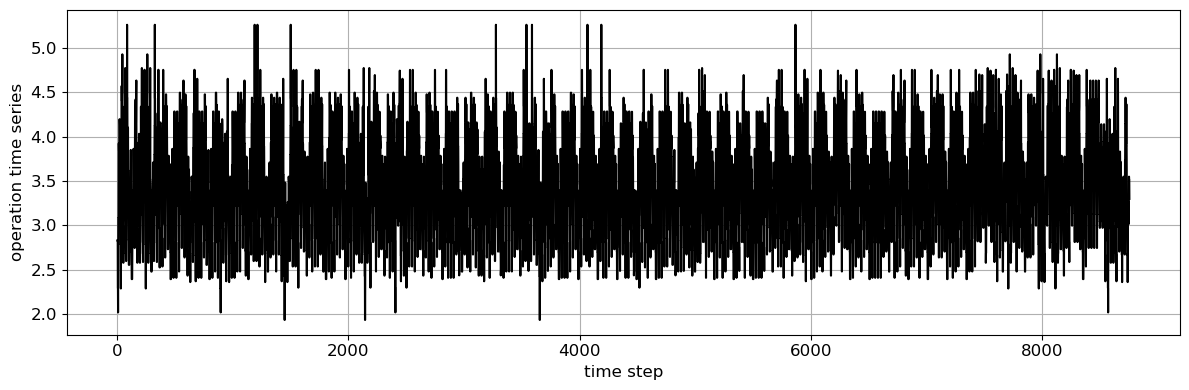

In [19]:
fig, ax = fn.plotOperation(esM, "Electricity demand", "GermanyRegion")

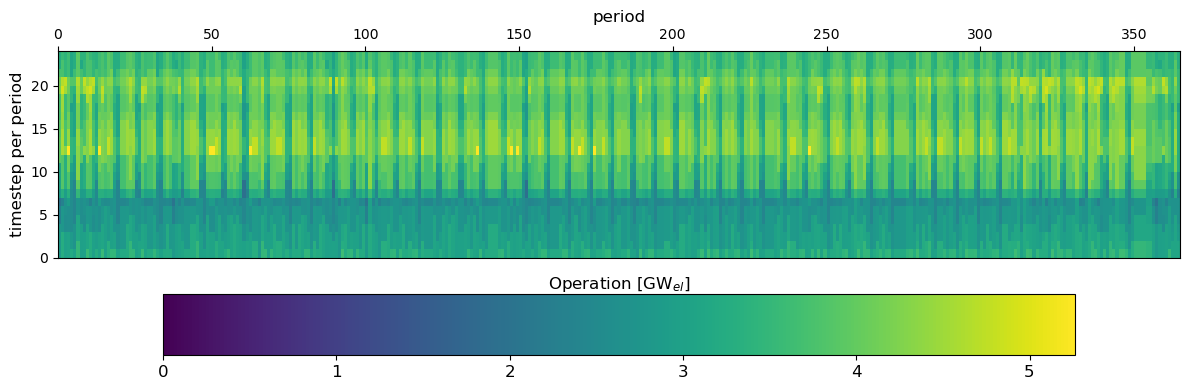

In [20]:
fig, ax = fn.plotOperationColorMap(esM, "Electricity demand", "GermanyRegion")

### Conversion

Show optimization summary

In [21]:
esM.getOptimizationSummary("ConversionModel", outputLevel=1)

GermanyRegion
Component                  Property                        Unit                         
Electroylzers              NPVcontribution                 [1e9 Euro]            0.41866
                           TAC                             [1e9 Euro/a]          0.41866
                           capacity                        [GW$_{el}$]          4.811365
                           capexCap                        [1e9 Euro/a]         0.358518
                           commissioning                   [GW$_{el}$]          4.811365
                           decommissioning                 [GW$_{el}$]               0.0
                           invest                          [1e9 Euro]           2.405682
                           investLifetimeExtension         [1e9 Euro]                  0
                           operation                       [GW$_{el}$*h/a]  16466.440288
                                                           [GW$_{el}$*h]    16466.440288
                           opexCap                         [1e9 Euro/a]         0.060142
                           opexOp                          [1e9 Euro/a]              0.0
                           revenueLifetimeShorteningResale [1e9 Euro]                  0
New CCGT plants (hydrogen) NPVcontribution                 [1e9 Euro]           0.124833
                           TAC                             [1e9 Euro/a]         0.124833
                           capacity                        [GW$_{el}$]          1.526151
                           capexCap                        [1e9 Euro/a]         0.092784
                           commissioning                   [GW$_{el}$]          1.526151
                           decommissioning                 [GW$_{el}$]               0.0
                           invest                          [1e9 Euro]           1.068306
                           investLifetimeExtension         [1e9 Euro]                  0
                           operation                       [GW$_{el}$*h/a]   4056.859995
                                                           [GW$_{el}$*h]     4056.859995
                           opexCap                         [1e9 Euro/a]         0.032049
                           opexOp                          [1e9 Euro/a]              0.0
                           revenueLifetimeShorteningResale [1e9 Euro]                  0

In [22]:
#fig, ax = fn.plotOperationColorMap(esM, "New CCGT plants (hydrogen)", "GermanyRegion")

### Storage

Show optimization summary

In [23]:
esM.getOptimizationSummary("StorageModel", outputLevel=2)

GermanyRegion
Component               Property           Unit                                
Li-ion batteries        NPVcontribution    [1e9 Euro]                  2.263225
                        TAC                [1e9 Euro/a]                2.263225
                        capacity           [GW$_{el}$*h]             134.692969
                        capexCap           [1e9 Euro/a]                1.993839
                        commissioning      [GW$_{el}$*h]             134.692969
                        invest             [1e9 Euro]                 20.338638
                        operationCharge    [GW$_{el}$*h/a]          6829.822338
                                           [GW$_{el}$*h]            6829.822338
                        operationDischarge [GW$_{el}$*h/a]          6140.784809
                                           [GW$_{el}$*h]            6140.784809
                        opexCap            [1e9 Euro/a]                0.269386
Salt caverns (hydrogen) NPVcontribution    [1e9 Euro]                  0.716143
                        TAC                [1e9 Euro/a]                0.716143
                        capacity           [GW$_{H_{2},LHV}$*h]     1235.216115
                        capexCap           [1e9 Euro/a]                0.012069
                        commissioning      [GW$_{H_{2},LHV}$*h]     1235.216115
                        invest             [1e9 Euro]                  0.135874
                        operationCharge    [GW$_{H_{2},LHV}$*h/a]    9260.09585
                                           [GW$_{H_{2},LHV}$*h]      9260.09585
                        operationDischarge [GW$_{H_{2},LHV}$*h/a]    9260.09585
                                           [GW$_{H_{2},LHV}$*h]      9260.09585
                        opexCap            [1e9 Euro/a]                0.704073

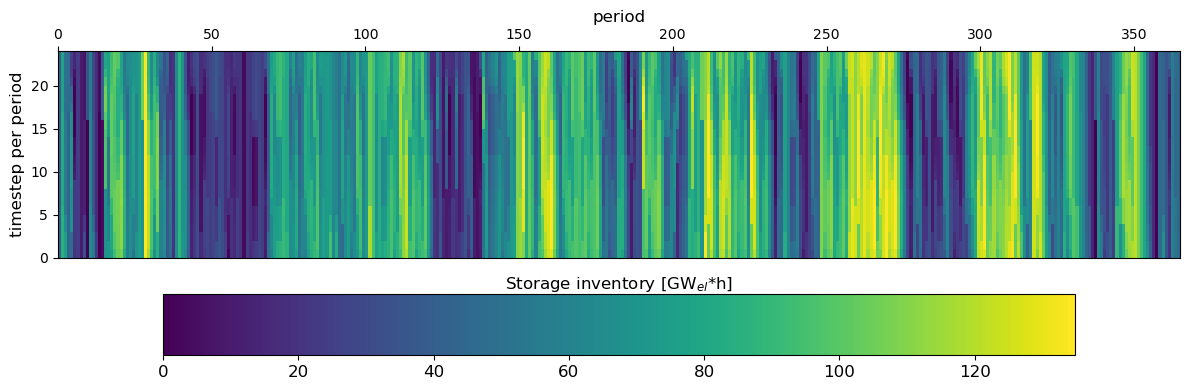

In [24]:
fig, ax = fn.plotOperationColorMap(
    esM,
    "Li-ion batteries",
    "GermanyRegion",
    variableName="stateOfChargeOperationVariablesOptimum",
)

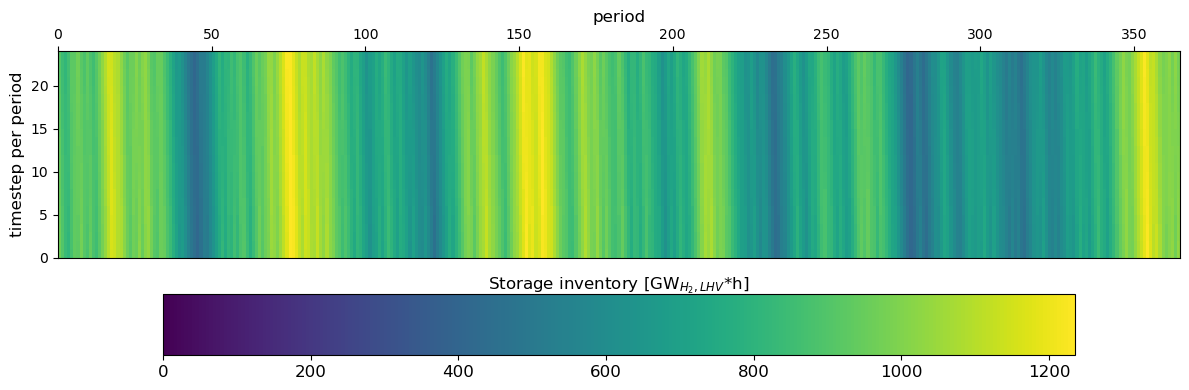

In [25]:
fig, ax = fn.plotOperationColorMap(
    esM,
    "Salt caverns (hydrogen)",
    "GermanyRegion",
    variableName="stateOfChargeOperationVariablesOptimum",
)